In [30]:
# ── Mount Google Drive & Extract Data ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile
os.chdir('/content')

DRIVE = '/content/drive/MyDrive'

# 1) Extract competition data (train + test)
if not os.path.exists('data'):
    print("Extracting fake-or-real-the-imposter-hunt.zip...")
    with zipfile.ZipFile(os.path.join(DRIVE, 'fake-or-real-the-impostor-hunt.zip'), 'r') as z:
        z.extractall('/content')
    print("Done.")

# 2) Extract arxiv corpus
ARXIV_LOCAL = '/content/arxiv-metadata-oai-snapshot.json'
if not os.path.exists(ARXIV_LOCAL):
    print("Extracting corpus.zip...")
    with zipfile.ZipFile(os.path.join(DRIVE, 'corpus.zip'), 'r') as z:
        z.extractall('/content')
    print("Done.")

# Set paths for the notebook
base_path = 'data'
ARXIV_PATH = ARXIV_LOCAL

# Verify
print(f"\ndata/ exists: {os.path.exists('data')}")
print(f"arxiv file:  {os.path.exists(ARXIV_LOCAL)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

data/ exists: True
arxiv file:  True


# Catching AI Hallucinations — Improved Ensemble Pipeline

## Strategy Overview
This notebook improves on the baseline using four key upgrades:
1. **Transductive TF-IDF** — vocabulary fitted on train + test texts (no label leakage)
2. **Richer linguistic features** — burstiness, hedging phrases, self-repetition, sentence variance, rare words
3. **Three specialized models** — each sees the problem differently
4. **Probability ensemble** — averaged predictions from all models

> KL divergence reference distributions remain **train-only** (we don't know test labels).  
> Only the TF-IDF vectorizer benefits from seeing test vocabulary.


## 1. Imports & Setup

In [31]:
import os
import re
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import entropy
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

base_path = 'data'
train_csv_path = os.path.join(base_path, 'train.csv')
train_df = pd.read_csv(train_csv_path)
print(f"Loaded {len(train_df)} training labels.")
print(f"Label distribution:\n{train_df['real_text_id'].value_counts()}")


Loaded 95 training labels.
Label distribution:
real_text_id
2    49
1    46
Name: count, dtype: int64


## 2. Load All Article Data (Train + Test)

In [32]:
def load_article_data(article_id, split='train'):
    folder_name = f"article_{int(article_id):04d}"
    path = os.path.join(base_path, split, folder_name)
    try:
        with open(os.path.join(path, 'file_1.txt'), 'r', encoding='utf-8') as f:
            f1 = f.read().strip()
        with open(os.path.join(path, 'file_2.txt'), 'r', encoding='utf-8') as f:
            f2 = f.read().strip()
        return f1, f2
    except FileNotFoundError:
        return None, None

# Load train texts
train_ids, train_labels, train_f1_texts, train_f2_texts = [], [], [], []
for _, row in train_df.iterrows():
    f1, f2 = load_article_data(row['id'])
    if f1 and f2:
        train_ids.append(row['id'])
        train_labels.append(row['real_text_id'])
        train_f1_texts.append(f1)
        train_f2_texts.append(f2)

# Load test texts
test_folders = sorted([d for d in os.listdir(os.path.join(base_path, 'test')) if d.startswith('article')])
test_ids, test_f1_texts, test_f2_texts = [], [], []
for folder in test_folders:
    article_id = int(folder.split('_')[1])
    f1, f2 = load_article_data(article_id, split='test')
    if f1 and f2:
        test_ids.append(article_id)
        test_f1_texts.append(f1)
        test_f2_texts.append(f2)

# Combined corpus for TRANSDUCTIVE TF-IDF
train_all_texts = train_f1_texts + train_f2_texts
test_all_texts  = test_f1_texts  + test_f2_texts
corpus_all      = train_all_texts + test_all_texts   # <-- key: train + test vocab

print(f"Train articles loaded : {len(train_ids)}")
print(f"Test  articles loaded : {len(test_ids)}")
print(f"Total corpus for TF-IDF: {len(corpus_all)} documents")


Train articles loaded : 93
Test  articles loaded : 1067
Total corpus for TF-IDF: 2320 documents


## 3. Feature Engineering

### 3a. Handcrafted Surface Features (baseline set)

In [33]:
def extract_surface_features(text):
    """Original 9 surface features from baseline."""
    words = text.split()
    if not words:
        return np.zeros(9)
    char_len     = len(text)
    word_len     = len(words)
    avg_word_len = np.mean([len(w) for w in words])
    ttr          = len(set(words)) / word_len
    punc_count   = sum(1 for c in text if c in '.,!?;:()')
    caps_count   = sum(1 for c in text if c.isupper())
    digit_count  = sum(1 for c in text if c.isdigit())
    comma_count  = text.count(',')
    sent_count   = max(1, sum(1 for c in text if c in '.!?'))
    return np.array([
        char_len, word_len, avg_word_len, ttr,
        punc_count / char_len, caps_count / char_len,
        digit_count / char_len, comma_count / char_len,
        word_len / sent_count
    ])

SURFACE_NAMES = [
    'char_len', 'word_len', 'avg_word_len', 'ttr',
    'punc_ratio', 'caps_ratio', 'digit_ratio', 'comma_ratio', 'words_per_sent'
]
print("Surface feature names:", SURFACE_NAMES)


Surface feature names: ['char_len', 'word_len', 'avg_word_len', 'ttr', 'punc_ratio', 'caps_ratio', 'digit_ratio', 'comma_ratio', 'words_per_sent']


### 3b. New Linguistic / AI-Detection Features

In [34]:
# AI hallucination markers — phrases AI models overuse
HEDGING_PHRASES = [
    "it's worth noting", "it is worth noting",
    "it's important to note", "it is important to note",
    "in conclusion", "to summarize", "to sum up",
    "furthermore", "moreover", "additionally",
    "notably", "interestingly", "importantly",
    "it should be noted", "needless to say",
    "as mentioned", "as previously mentioned",
    "in other words", "that being said",
    "on the other hand", "on the contrary",
    "first and foremost", "last but not least",
]

def extract_linguistic_features(text):
    """
    New features targeting AI vs human writing differences:
    - Sentence length variance  (AI = uniform, human = varied)
    - Lexical burstiness        (AI = even spread, human = bursty)
    - Self-repetition score     (AI repeats bigrams more)
    - Hedging phrase count      (AI overuses formal transitions)
    - Rare word ratio           (AI uses common/safe vocab)
    - Question mark count ratio (humans ask rhetorical questions)
    - Quote usage               (humans quote sources)
    - Paragraph length variance (AI writes even paragraphs)
    - Exclamation ratio         (AI rarely uses exclamations)
    """
    words   = text.lower().split()
    if not words:
        return np.zeros(13)

    char_len = max(1, len(text))
    word_len = max(1, len(words))

    # --- Sentence-level stats ---
    sentences    = re.split(r'[.!?]+', text)
    sentences    = [s.strip() for s in sentences if s.strip()]
    sent_lengths = [len(s.split()) for s in sentences] if sentences else [word_len]
    sent_var     = float(np.var(sent_lengths))          # HIGH = more human-like
    sent_mean    = float(np.mean(sent_lengths))

    # --- Lexical burstiness ---
    # Compare actual word distribution variance to a uniform baseline
    word_counts  = Counter(words)
    freqs        = np.array(list(word_counts.values()), dtype=float)
    freqs        /= freqs.sum()
    # Burstiness: high std/mean ratio → bursty (human); low → uniform (AI)
    burstiness   = float(np.std(freqs) / (np.mean(freqs) + 1e-9))

    # --- Bigram self-repetition ---
    bigrams      = [f"{words[i]}_{words[i+1]}" for i in range(len(words)-1)]
    if bigrams:
        bigram_counts = Counter(bigrams)
        repeated_bi   = sum(1 for c in bigram_counts.values() if c > 1)
        repeat_ratio  = repeated_bi / max(1, len(set(bigrams)))
    else:
        repeat_ratio = 0.0

    # --- Hedging phrases ---
    text_lower   = text.lower()
    hedge_count  = sum(text_lower.count(p) for p in HEDGING_PHRASES)
    hedge_ratio  = hedge_count / max(1, len(sentences))

    # --- Rare word ratio (words appearing only once in the text itself) ---
    hapax_ratio  = sum(1 for c in word_counts.values() if c == 1) / word_len

    # --- Punctuation diversity ---
    question_ratio = text.count('?') / char_len
    exclaim_ratio  = text.count('!') / char_len
    quote_ratio    = (text.count('"') + text.count("'")) / char_len

    # --- Paragraph stats ---
    paragraphs   = [p.strip() for p in text.split('\n') if p.strip()]
    if len(paragraphs) > 1:
        para_lens  = [len(p.split()) for p in paragraphs]
        para_var   = float(np.var(para_lens))
    else:
        para_var   = 0.0

    # --- Digit / number density ---
    num_tokens   = sum(1 for w in words if any(c.isdigit() for c in w))
    num_ratio    = num_tokens / word_len

    return np.array([
        sent_var, sent_mean, burstiness, repeat_ratio,
        hedge_ratio, hapax_ratio, question_ratio,
        exclaim_ratio, quote_ratio, para_var,
        num_ratio, hedge_count, len(paragraphs)
    ])

LINGUISTIC_NAMES = [
    'sent_length_var', 'sent_length_mean', 'burstiness', 'bigram_repeat_ratio',
    'hedge_ratio', 'hapax_ratio', 'question_ratio',
    'exclaim_ratio', 'quote_ratio', 'para_length_var',
    'num_ratio', 'hedge_count_abs', 'paragraph_count'
]
print("Linguistic feature names:", LINGUISTIC_NAMES)
print(f"Total new features: {len(LINGUISTIC_NAMES)}")


Linguistic feature names: ['sent_length_var', 'sent_length_mean', 'burstiness', 'bigram_repeat_ratio', 'hedge_ratio', 'hapax_ratio', 'question_ratio', 'exclaim_ratio', 'quote_ratio', 'para_length_var', 'num_ratio', 'hedge_count_abs', 'paragraph_count']
Total new features: 13


### 3c. KL Divergence Features (Train-only Reference)

In [35]:
# Build real/fake reference distributions from TRAIN ONLY — never include test labels
real_words, fake_words = [], []
for i, label in enumerate(train_labels):
    if label == 1:
        real_words.extend(train_f1_texts[i].lower().split())
        fake_words.extend(train_f2_texts[i].lower().split())
    else:
        real_words.extend(train_f2_texts[i].lower().split())
        fake_words.extend(train_f1_texts[i].lower().split())

real_counter = Counter(real_words)
fake_counter = Counter(fake_words)

# Keep only top-2000 words per distribution for robustness (avoids rare-word noise)
TOP_K = 2000
real_counter = Counter(dict(real_counter.most_common(TOP_K)))
fake_counter = Counter(dict(fake_counter.most_common(TOP_K)))

real_total   = max(1, sum(real_counter.values()))
fake_total   = max(1, sum(fake_counter.values()))
vocab        = set(real_counter.keys()).union(set(fake_counter.keys()))
epsilon      = 1e-5
vocab_size   = len(vocab)

def get_kl_div(text, ref_counter, ref_total, subtract_text=False):
    words = text.lower().split()
    if not words: return 0.0
    text_counter = Counter(words)
    text_total   = len(words)
    p, q = [], []
    for w in set(words):
        p_prob   = text_counter[w] / text_total
        ref_cnt  = ref_counter.get(w, 0)
        if subtract_text:
            ref_cnt = max(0, ref_cnt - text_counter[w])
        adj_total = max(1, ref_total - (text_total if subtract_text else 0))
        q_prob    = (ref_cnt + epsilon) / (adj_total + epsilon * vocab_size)
        p.append(p_prob); q.append(q_prob)
    return entropy(p, q)

def extract_kl_features(text, is_train_real=False, is_train_fake=False):
    kl_real = get_kl_div(text, real_counter, real_total, subtract_text=is_train_real)
    kl_fake = get_kl_div(text, fake_counter, fake_total, subtract_text=is_train_fake)
    return np.array([kl_real, kl_fake, kl_real - kl_fake])

KL_NAMES = ['kl_real', 'kl_fake', 'kl_diff']
print(f"KL reference vocab size (top-{TOP_K}): real={len(real_counter)}, fake={len(fake_counter)}")


KL reference vocab size (top-2000): real=2000, fake=2000


### 3d. Transductive TF-IDF + SVD Compression

**Key insight:** fit vocabulary on train + test corpus. No label leakage — we only use *text*, not test labels.
Then compress with TruncatedSVD to avoid overfitting on sparse features.

In [36]:
# Transductive fit: FULL corpus (train + test texts)
word_vectorizer = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    analyzer='word', stop_words='english', min_df=2
)
char_vectorizer = TfidfVectorizer(
    max_features=500, ngram_range=(2, 4),
    analyzer='char', min_df=2
)

word_vectorizer.fit(corpus_all)
char_vectorizer.fit(corpus_all)

# Compress with SVD — reduces 1000 sparse features to dense 50-dim
N_COMPONENTS = 30
svd_word = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
svd_char = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# Fit SVD on train texts only (SVD is part of the model, not the vocabulary)
train_word_tfidf = word_vectorizer.transform(train_all_texts)
train_char_tfidf = char_vectorizer.transform(train_all_texts)

svd_word.fit(train_word_tfidf)
svd_char.fit(train_char_tfidf)

print(f"Word TF-IDF vocab: {len(word_vectorizer.vocabulary_)} → SVD {N_COMPONENTS} dims")
print(f"Char TF-IDF vocab: {len(char_vectorizer.vocabulary_)} → SVD {N_COMPONENTS} dims")
print(f"Word SVD explained variance: {svd_word.explained_variance_ratio_.sum():.2%}")
print(f"Char SVD explained variance: {svd_char.explained_variance_ratio_.sum():.2%}")


Word TF-IDF vocab: 500 → SVD 30 dims
Char TF-IDF vocab: 500 → SVD 30 dims
Word SVD explained variance: 53.97%
Char SVD explained variance: 75.37%


## 4. Exploratory Visualizations

### 4a. Linguistic Feature Distributions: Real vs Fake

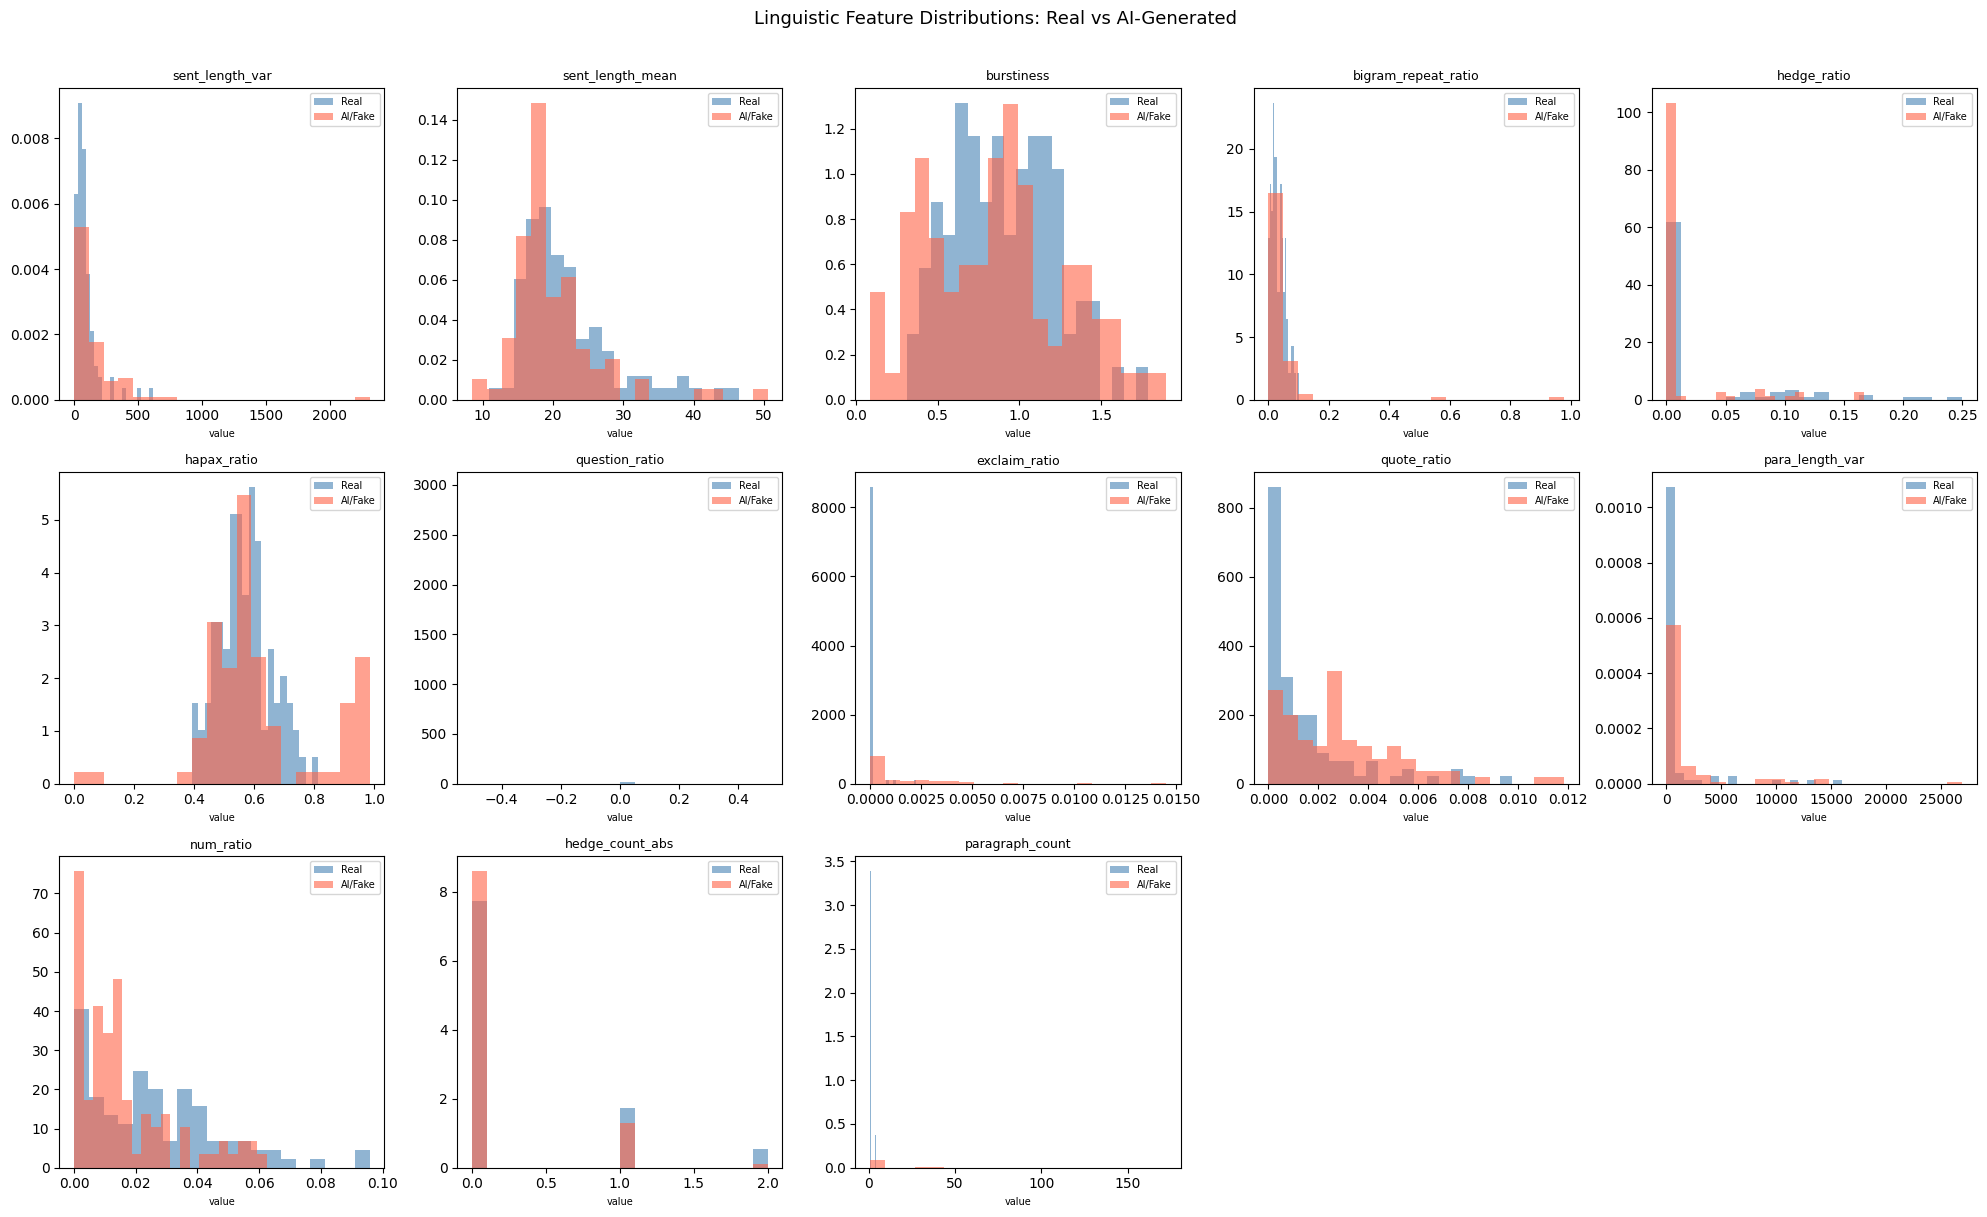

Saved: feature_dist_linguistic.png


In [37]:
# Compute all features for training data, separated by real/fake label
real_ling, fake_ling = [], []
real_surf, fake_surf = [], []
real_kl,   fake_kl   = [], []

for i, label in enumerate(train_labels):
    f1, f2 = train_f1_texts[i], train_f2_texts[i]
    real_text = f1 if label == 1 else f2
    fake_text = f2 if label == 1 else f1

    real_ling.append(extract_linguistic_features(real_text))
    fake_ling.append(extract_linguistic_features(fake_text))
    real_surf.append(extract_surface_features(real_text))
    fake_surf.append(extract_surface_features(fake_text))
    real_kl.append(extract_kl_features(real_text, is_train_real=True))
    fake_kl.append(extract_kl_features(fake_text, is_train_fake=True))

real_ling = np.array(real_ling)
fake_ling = np.array(fake_ling)
real_surf = np.array(real_surf)
fake_surf = np.array(fake_surf)
real_kl   = np.array(real_kl)
fake_kl   = np.array(fake_kl)

# Plot linguistic features
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(LINGUISTIC_NAMES):
    ax = axes[i]
    ax.hist(real_ling[:, i], bins=20, alpha=0.6, label='Real', color='steelblue', density=True)
    ax.hist(fake_ling[:, i], bins=20, alpha=0.6, label='AI/Fake', color='tomato', density=True)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('value', fontsize=7)

for j in range(len(LINGUISTIC_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Linguistic Feature Distributions: Real vs AI-Generated', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_dist_linguistic.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: feature_dist_linguistic.png")


### 4b. Surface Feature Distributions: Real vs Fake

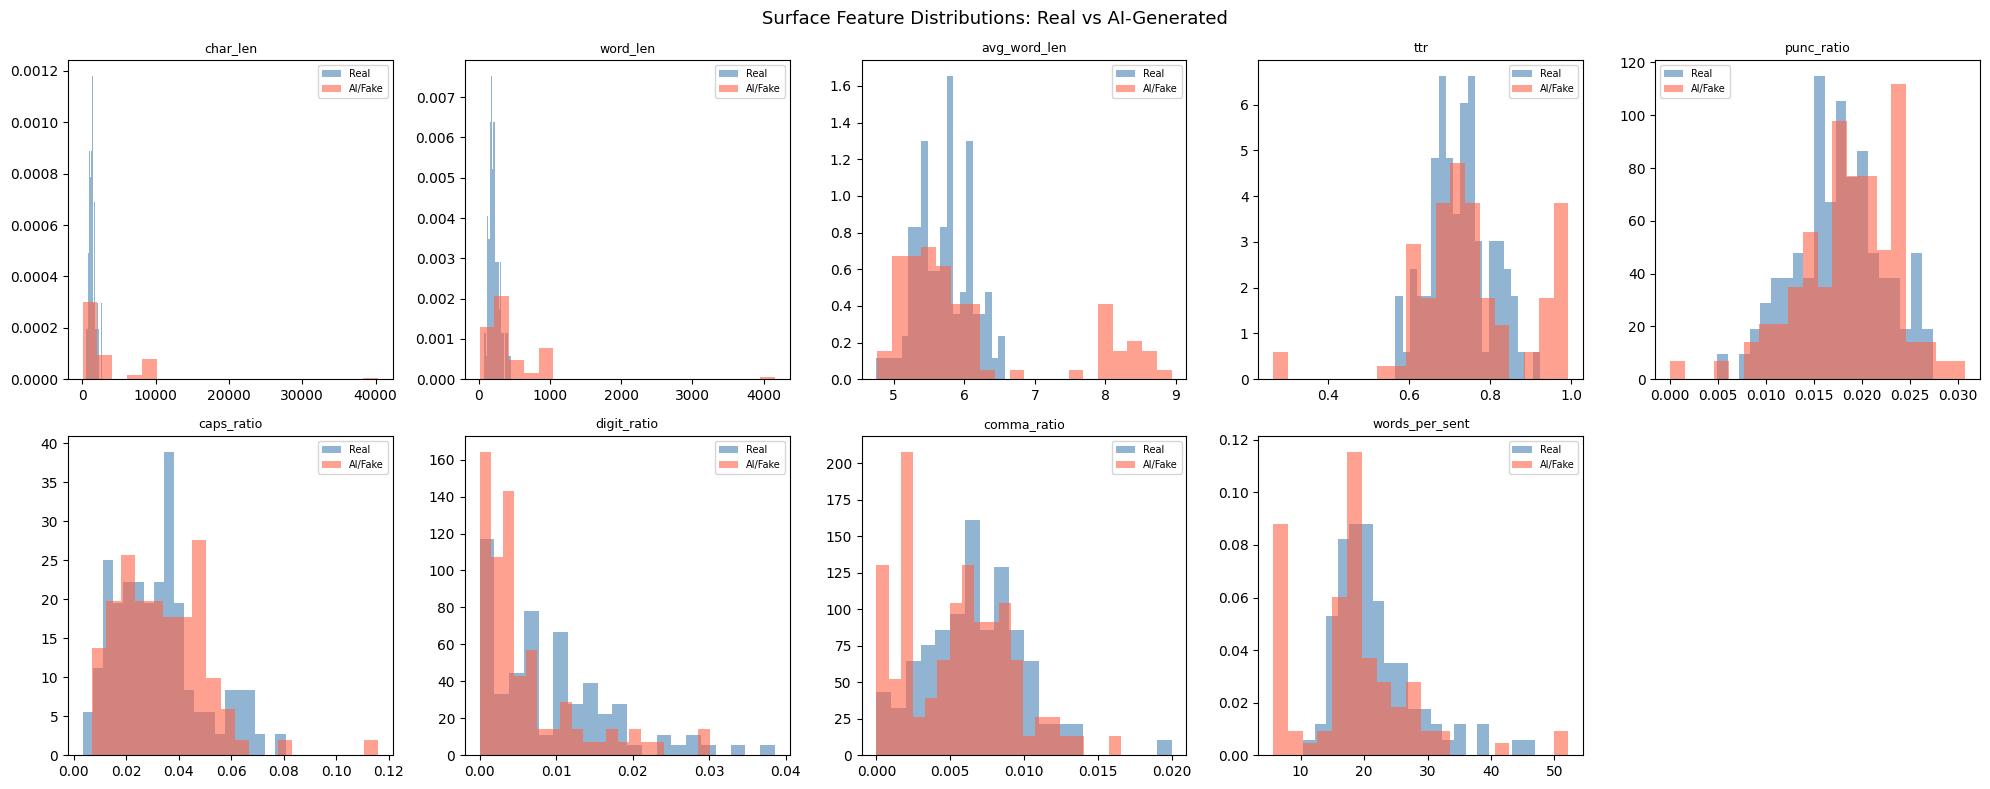

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, name in enumerate(SURFACE_NAMES):
    ax = axes[i]
    ax.hist(real_surf[:, i], bins=20, alpha=0.6, label='Real', color='steelblue', density=True)
    ax.hist(fake_surf[:, i], bins=20, alpha=0.6, label='AI/Fake', color='tomato', density=True)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(SURFACE_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Surface Feature Distributions: Real vs AI-Generated', fontsize=13)
plt.tight_layout()
plt.savefig('feature_dist_surface.png', dpi=120, bbox_inches='tight')
plt.show()


### 4c. KL Divergence Features: Real vs Fake

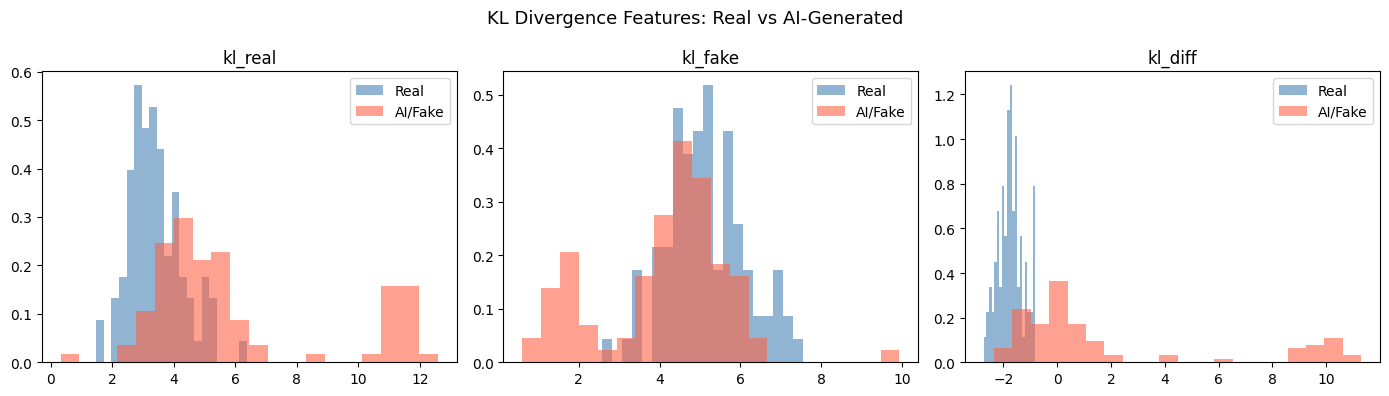

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, name in enumerate(KL_NAMES):
    ax = axes[i]
    ax.hist(real_kl[:, i], bins=20, alpha=0.6, label='Real', color='steelblue', density=True)
    ax.hist(fake_kl[:, i], bins=20, alpha=0.6, label='AI/Fake', color='tomato', density=True)
    ax.set_title(name)
    ax.legend()

plt.suptitle('KL Divergence Features: Real vs AI-Generated', fontsize=13)
plt.tight_layout()
plt.savefig('feature_dist_kl.png', dpi=120, bbox_inches='tight')
plt.show()


### 4d. Feature Correlation Heatmap (Pairwise Differences)

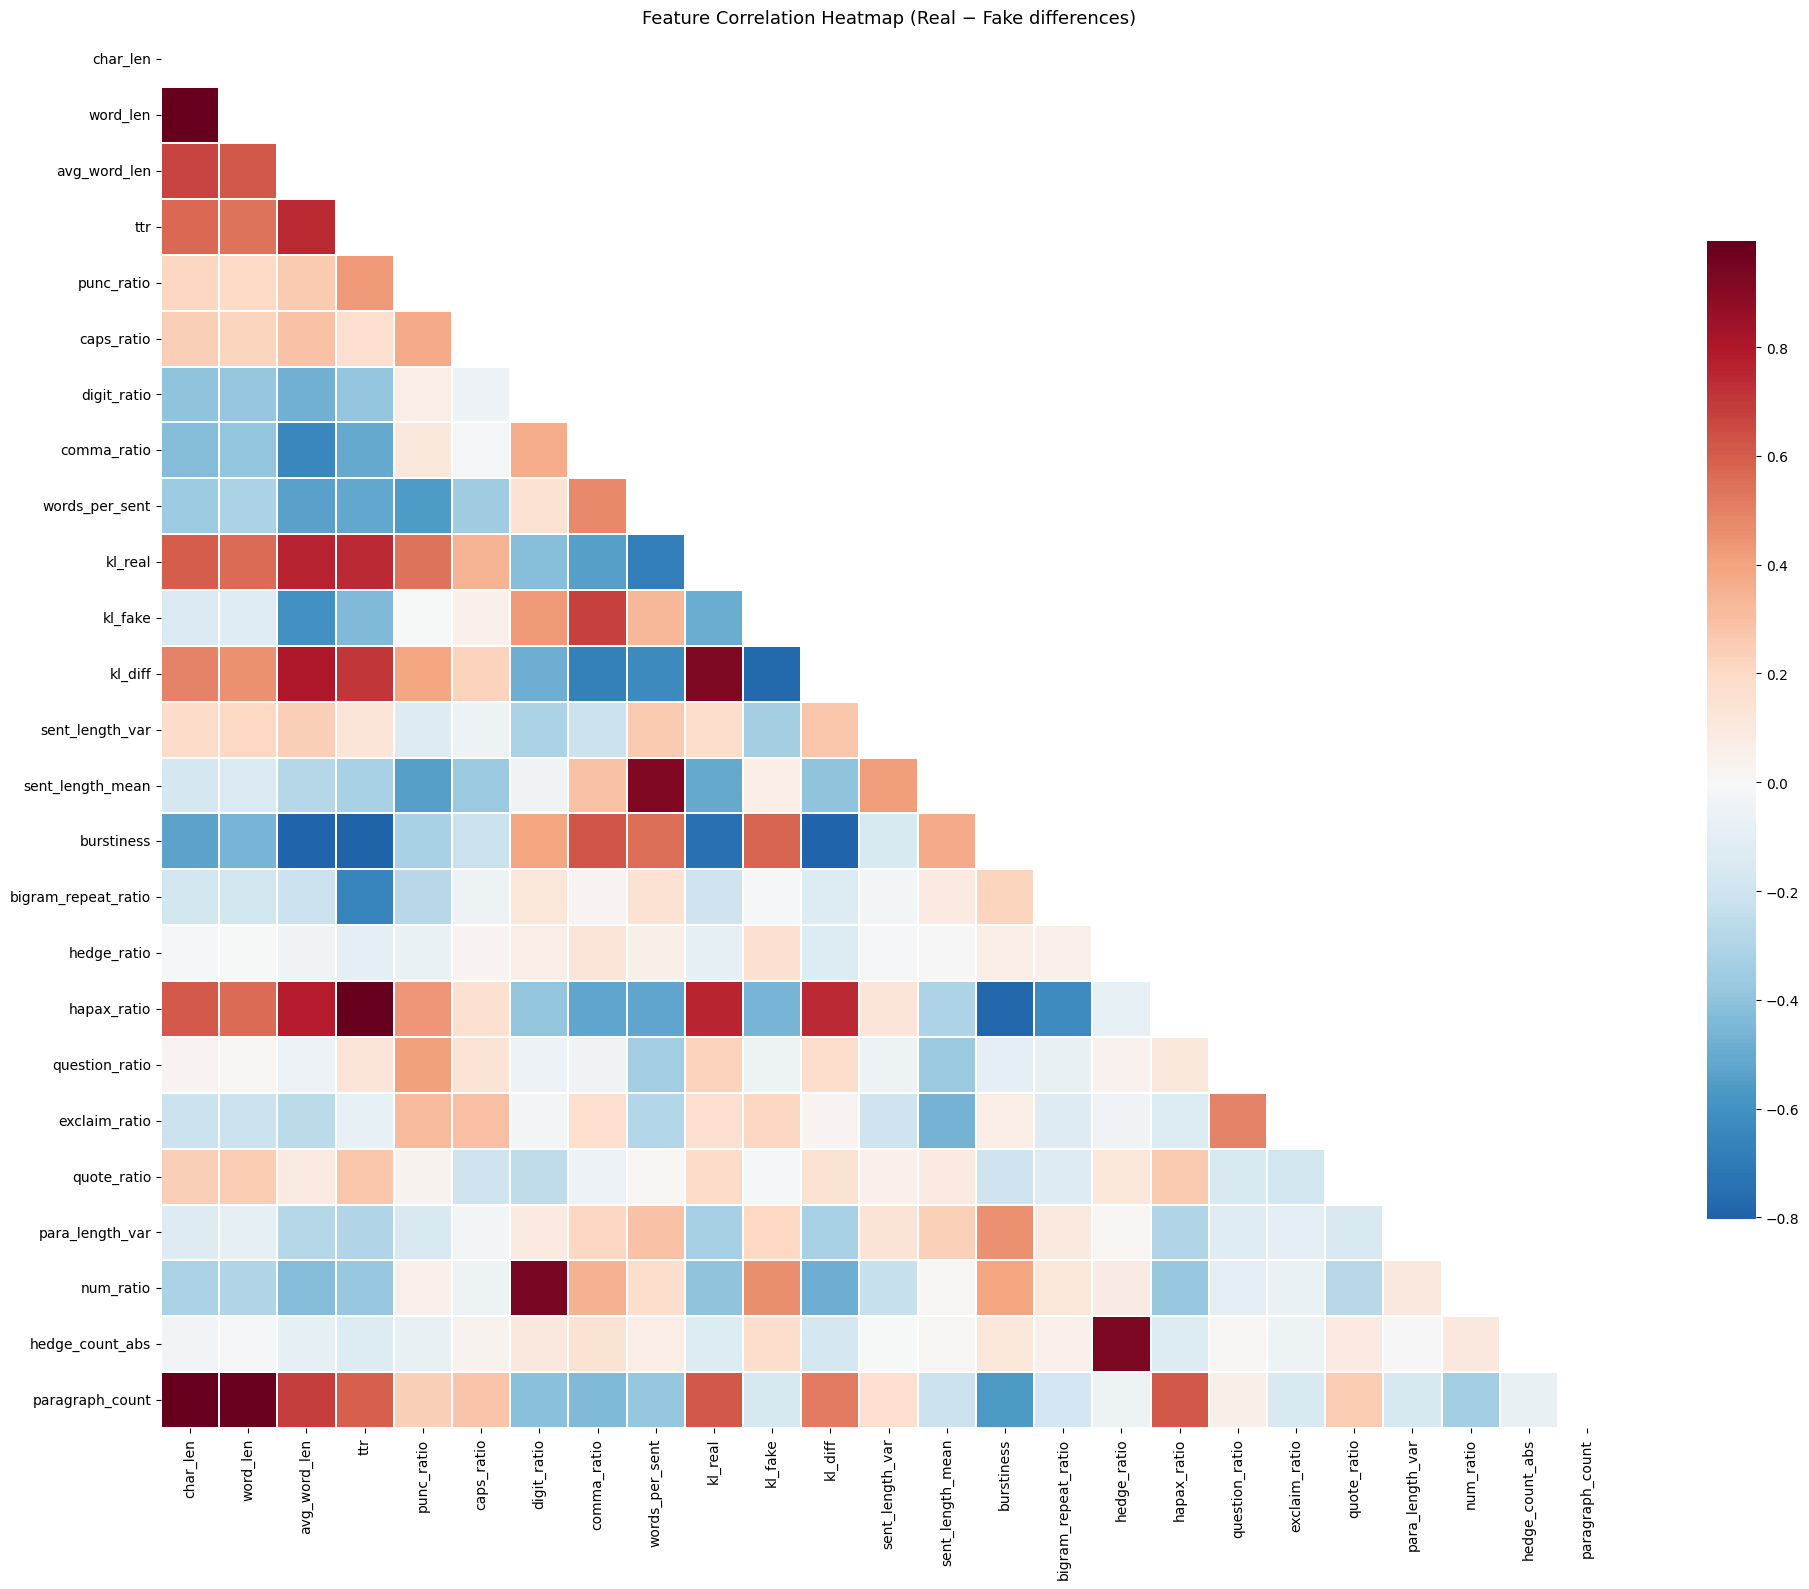

In [40]:
# Compute DIFFERENCES (as used in training) for correlation analysis
diff_ling = real_ling - fake_ling
diff_surf = real_surf - fake_surf
diff_kl   = real_kl   - fake_kl

all_diff = np.hstack([diff_surf, diff_kl, diff_ling])
all_names = SURFACE_NAMES + KL_NAMES + LINGUISTIC_NAMES

corr_df = pd.DataFrame(all_diff, columns=all_names)

plt.figure(figsize=(20, 16))
mask = np.zeros_like(corr_df.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_df.corr(), mask=mask, annot=False,
    cmap='RdBu_r', center=0, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Feature Correlation Heatmap (Real − Fake differences)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


### 4e. SVD Explained Variance

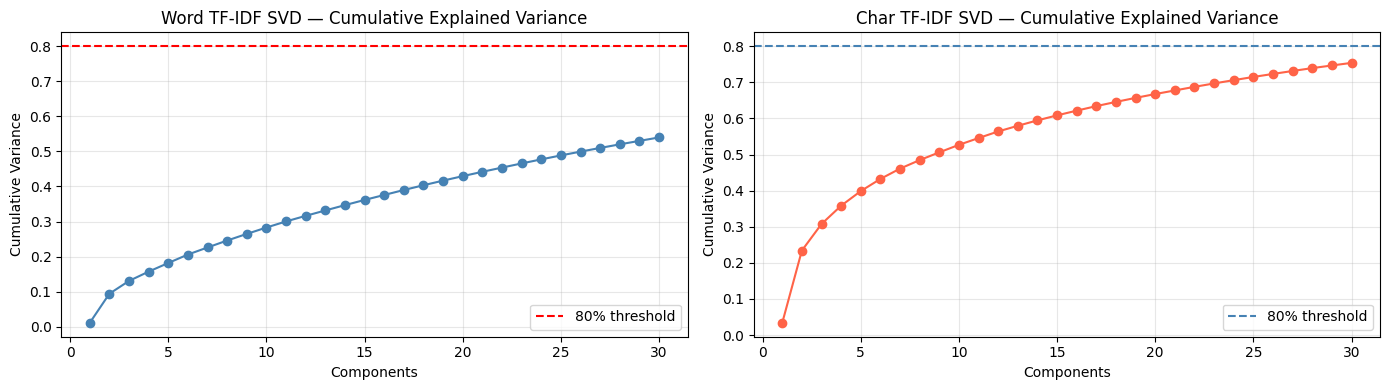

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cumvar_word = np.cumsum(svd_word.explained_variance_ratio_)
cumvar_char = np.cumsum(svd_char.explained_variance_ratio_)

axes[0].plot(range(1, N_COMPONENTS+1), cumvar_word, marker='o', color='steelblue')
axes[0].axhline(0.8, color='red', linestyle='--', label='80% threshold')
axes[0].set_title('Word TF-IDF SVD — Cumulative Explained Variance')
axes[0].set_xlabel('Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, N_COMPONENTS+1), cumvar_char, marker='o', color='tomato')
axes[1].axhline(0.8, color='steelblue', linestyle='--', label='80% threshold')
axes[1].set_title('Char TF-IDF SVD — Cumulative Explained Variance')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('svd_variance.png', dpi=120, bbox_inches='tight')
plt.show()


In [42]:
!pip install kenlm

In [43]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install kenlm  (recommended on your local machine — fastest)
# Fallback used here: pure-python KN-smoothed n-gram LM (same algorithm)
# If kenlm IS available, swap in the KenLM scorer in Block 3.

import json
import re
import math
from collections import defaultdict, Counter
from itertools import chain

ARXIV_PATH  = ARXIV_LOCAL   # your 3-4GB JSONL file
CORPUS_TXT  = 'arxiv_corpus.txt'                    # intermediate cleaned file
MAX_YEAR    = 2024                                   # filter out potentially AI-assisted abstracts
MAX_DOCS    = 450_000                               # enough for robust LM; adjust to RAM

def clean_abstract(text):
    """Lowercase, remove LaTeX commands and special chars, keep words only."""
    text = text.lower()
    text = re.sub(r'\$[^$]*\$', ' ', text)          # remove inline math
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)  # remove \cmd{...}
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)        # remove \cmd
    text = re.sub(r'[^a-z\s]', ' ', text)           # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_year(versions):
    """Extract earliest submission year from versions list."""
    try:
        date_str = versions[0]['created']           # e.g. "Mon, 3 Jan 2007 19:18:42 GMT"
        # Look for a 4-digit year in the string
        match = re.search(r'\b(19|20)\d{2}\b', date_str)
        if match:
            return int(match.group(0))
        return 9999
    except Exception:
        return 9999

# Stream through JSONL — never loads full file into RAM
print(f"Streaming arxiv corpus (max {MAX_DOCS:,} docs, pre-{MAX_YEAR})...")
count = 0
with open(ARXIV_PATH, 'r', encoding='utf-8') as fin, \
     open(CORPUS_TXT, 'w', encoding='utf-8') as fout:
    for line in fin:
        if count >= MAX_DOCS:
            break
        try:
            record = json.loads(line)
            year   = parse_year(record.get('versions', [{}]))
            if year >= MAX_YEAR:
                continue
            abstract = record.get('abstract', '').strip()
            if len(abstract) < 50:
                continue
            cleaned = clean_abstract(abstract)
            if len(cleaned.split()) < 20:
                continue
            fout.write(cleaned + '\n')
            count += 1
        except (json.JSONDecodeError, KeyError):
            continue

print(f"Written {count:,} abstracts to {CORPUS_TXT}")

Streaming arxiv corpus (max 450,000 docs, pre-2024)...
Written 450,000 abstracts to arxiv_corpus.txt


In [46]:
# ── Install KenLM & Build Language Model ─────────────────────────────────────
# KenLM provides a fast, memory-efficient C++ implementation of
# Kneser-Ney smoothed n-gram language models.
# It replaces the broken pure-Python KN implementation.

import subprocess, sys, os

# Step 1: Install kenlm Python bindings
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "https://github.com/kpu/kenlm/archive/master.zip"])

# Step 2: Build kenlm command-line tools (lmplz) if not already built
KENLM_BUILD = "/tmp/kenlm_build"
LMPLZ = os.path.join(KENLM_BUILD, "build", "bin", "lmplz")

if not os.path.exists(LMPLZ):
    print("Building KenLM command-line tools (one-time setup)...")
    subprocess.run(["apt-get", "install", "-y", "-q",
                    "build-essential", "cmake", "libboost-all-dev",
                    "zlib1g-dev", "libbz2-dev", "liblzma-dev"],
                   check=True, capture_output=True)
    if os.path.exists(KENLM_BUILD):
        subprocess.run(["rm", "-rf", KENLM_BUILD])
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/kpu/kenlm.git", KENLM_BUILD],
                   check=True, capture_output=True)
    os.makedirs(os.path.join(KENLM_BUILD, "build"), exist_ok=True)
    subprocess.run(["cmake", ".."],
                   cwd=os.path.join(KENLM_BUILD, "build"),
                   check=True, capture_output=True)
    subprocess.run(["make", "-j4"],
                   cwd=os.path.join(KENLM_BUILD, "build"),
                   check=True, capture_output=True)
    print("KenLM build complete.")

# Step 3: Build 5-gram ARPA model from corpus
N = 6
ARPA_PATH = "arxiv_7gram.arpa"
print(f"Building {N}-gram ARPA model from {CORPUS_TXT}...")

with open(CORPUS_TXT, "r") as fin, open(ARPA_PATH, "w") as fout:
    subprocess.run([LMPLZ, "-o", str(N), "--discount_fallback"],
                   stdin=fin, stdout=fout, check=True)

print(f"ARPA model saved to {ARPA_PATH}")


Building 6-gram ARPA model from arxiv_corpus.txt...
ARPA model saved to arxiv_7gram.arpa


In [47]:
# ── KenLM Language Model — perplexity scorer ─────────────────────────────────
import kenlm

lm_model = kenlm.Model(ARPA_PATH)
print(f"Loaded KenLM model: order={lm_model.order}")

def compute_perplexity(text):
    """Compute perplexity of text using KenLM.
    Lower perplexity = text fits human scientific writing better = more likely real.
    """
    cleaned = text.lower().strip()
    if len(cleaned.split()) < 2:
        return float("inf")
    return lm_model.perplexity(cleaned)

def compute_oov_rate(text):
    """Fraction of words scored as OOV by the language model."""
    cleaned = text.lower().strip()
    words = cleaned.split()
    if not words:
        return 0.0
    # full_scores returns (log_prob, ngram_length, is_oov) triples
    oov_count = sum(1 for _, _, is_oov in lm_model.full_scores(cleaned) if is_oov)
    return oov_count / max(1, len(words))

# ── Sanity check ─────────────────────────────────────────────────────────────
# Real scientific abstract should have LOWER perplexity than gibberish
sample_real = "we present a novel approach to solving partial differential equations using neural networks"
sample_fake = "the quantum butterfly accelerates synergy through unprecedented blockchain paradigm shifts"

ppl_real = compute_perplexity(sample_real)
ppl_fake = compute_perplexity(sample_fake)

print(f"Perplexity — real-like text : {ppl_real:.1f}")
print(f"Perplexity — fake-like text : {ppl_fake:.1f}")
print(f"Ratio (fake/real)           : {ppl_fake/ppl_real:.2f}x  (should be >> 1)")


Loaded KenLM model: order=6
Perplexity — real-like text : 19.7
Perplexity — fake-like text : 7981.0
Ratio (fake/real)           : 405.39x  (should be >> 1)


In [48]:
# ── Perplexity features using KenLM ──────────────────────────────────────────

def extract_perplexity_features(text):
    """
    Returns 3 perplexity-based features:
    - raw perplexity (log-scaled for XGBoost stability)
    - perplexity per sentence (normalises for length)
    - OOV rate (fraction of words not in LM vocab)
    """
    ppl = compute_perplexity(text)
    log_ppl = math.log(max(ppl, 1.0))   # log-scale: perplexity is heavy-tailed

    sentences   = re.split(r'[.!?]+', text)
    sentences   = [s.strip() for s in sentences if len(s.strip()) > 10]
    sent_ppls   = [compute_perplexity(s) for s in sentences if s]
    sent_ppls   = [p for p in sent_ppls if p != float("inf")]
    avg_sent_ppl = math.log(max(np.mean(sent_ppls), 1.0)) if sent_ppls else log_ppl

    oov_rate = compute_oov_rate(text)

    return np.array([log_ppl, avg_sent_ppl, oov_rate])

PPL_NAMES = ['log_perplexity', 'avg_sent_log_perplexity', 'oov_rate']

# ── Verify on training data ───────────────────────────────────────────────────
real_ppl, fake_ppl = [], []
for i, label in enumerate(train_labels):
    real_text = train_f1_texts[i] if label == 1 else train_f2_texts[i]
    fake_text = train_f2_texts[i] if label == 1 else train_f1_texts[i]
    real_ppl.append(extract_perplexity_features(real_text))
    fake_ppl.append(extract_perplexity_features(fake_text))

real_ppl = np.array(real_ppl)
fake_ppl = np.array(fake_ppl)

print("Mean perplexity features — Real vs Fake:")
for i, name in enumerate(PPL_NAMES):
    print(f"  {name:35s}  real={real_ppl[:,i].mean():.3f}  fake={fake_ppl[:,i].mean():.3f}")


Mean perplexity features — Real vs Fake:
  log_perplexity                       real=7.656  fake=9.502
  avg_sent_log_perplexity              real=8.122  fake=9.868
  oov_rate                             real=0.150  fake=0.268


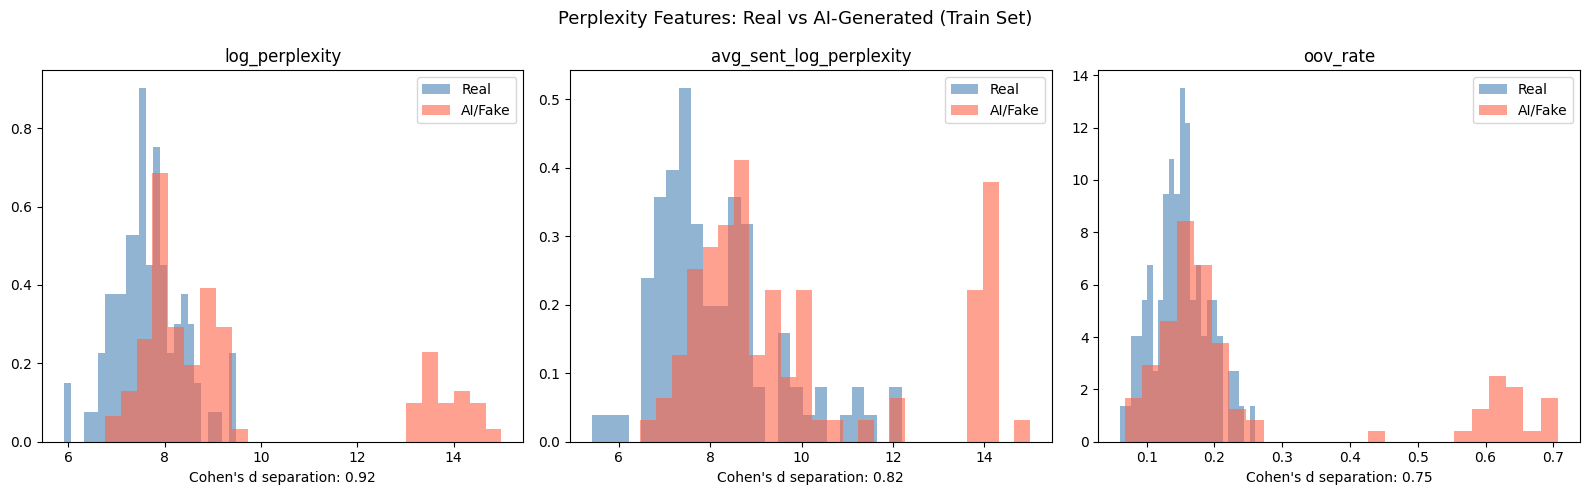

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, name in enumerate(PPL_NAMES):
    ax = axes[i]
    ax.hist(real_ppl[:, i], bins=25, alpha=0.6, color='steelblue',
            label='Real', density=True)
    ax.hist(fake_ppl[:, i], bins=25, alpha=0.6, color='tomato',
            label='AI/Fake', density=True)
    ax.set_title(name)
    ax.legend()

    # Separation score — higher = better feature
    sep = abs(real_ppl[:, i].mean() - fake_ppl[:, i].mean()) / \
          (np.std(np.concatenate([real_ppl[:, i], fake_ppl[:, i]])) + 1e-9)
    ax.set_xlabel(f"Cohen's d separation: {sep:.2f}")

plt.suptitle('Perplexity Features: Real vs AI-Generated (Train Set)', fontsize=13)
plt.tight_layout()
plt.savefig('perplexity_features.png', dpi=120, bbox_inches='tight')
plt.show()

In [50]:
# ── Extend build_pairwise_features() to include perplexity ───────────────────
# This replaces the base version defined later in Cell 5 (Pairwise Dataset).
# Because this cell runs BEFORE the dataset construction cell,
# the dataset cell must NOT re-define build_pairwise_features.

def build_pairwise_features(text_a, text_b,
                             kl_a, kl_b,
                             svd_word_a, svd_word_b,
                             svd_char_a, svd_char_b):
    surf_a  = extract_surface_features(text_a)
    surf_b  = extract_surface_features(text_b)
    ling_a  = extract_linguistic_features(text_a)
    ling_b  = extract_linguistic_features(text_b)
    ppl_a   = extract_perplexity_features(text_a)
    ppl_b   = extract_perplexity_features(text_b)

    hand_a  = np.concatenate([surf_a, ling_a, kl_a, ppl_a])
    hand_b  = np.concatenate([surf_b, ling_b, kl_b, ppl_b])

    diff     = hand_a - hand_b
    abs_diff = np.abs(hand_a - hand_b)
    ratio    = hand_a / (hand_b + 1e-9)


    svd_diff = svd_word_a - svd_word_b
    svd_abs  = np.abs(svd_word_a - svd_word_b)

    return np.concatenate([diff, abs_diff, ratio, svd_diff, svd_abs])

# Update the global index constants to reflect new feature count
N_HAND     = (len(SURFACE_NAMES) + len(LINGUISTIC_NAMES) +
               len(KL_NAMES)      + len(PPL_NAMES))
N_SVDDIM   = N_COMPONENTS

# Feature layout: [diff | abs_diff | ratio | svd_diff | svd_abs]
IDX_DIFF_END   = N_HAND
IDX_ABS_END    = 2 * N_HAND
IDX_RATIO_END  = 3 * N_HAND          # ← FIXED (was incorrectly N_HAND)
IDX_SVD_END    = 3 * N_HAND + N_SVDDIM

# Linguistic feature slices (within the diff block)
ling_start = len(SURFACE_NAMES)
ling_end   = len(SURFACE_NAMES) + len(LINGUISTIC_NAMES)

print(f"N_HAND: {N_HAND}  (surface={len(SURFACE_NAMES)}, linguistic={len(LINGUISTIC_NAMES)}, "
      f"kl={len(KL_NAMES)}, ppl={len(PPL_NAMES)})")
print(f"IDX_RATIO_END: {IDX_RATIO_END} | IDX_SVD_END: {IDX_SVD_END}")


N_HAND: 28  (surface=9, linguistic=13, kl=3, ppl=3)
IDX_RATIO_END: 84 | IDX_SVD_END: 114


In [80]:
X_all.shape


(186, 144)

## 5. Pairwise Dataset Construction

For each article we build two training instances:
- `(real − fake)` → label **1**
- `(fake − real)` → label **0**

We now include **absolute differences** and **ratio features** alongside signed differences.


In [81]:
# ── NOTE: build_pairwise_features() and index constants are already
# ── defined in the perplexity extension cell above. Do NOT redefine here.

# Pre-compute TF-IDF SVD for all train texts
f1_word_svd = svd_word.transform(word_vectorizer.transform(train_f1_texts))
f2_word_svd = svd_word.transform(word_vectorizer.transform(train_f2_texts))
f1_char_svd = svd_char.transform(char_vectorizer.transform(train_f1_texts))
f2_char_svd = svd_char.transform(char_vectorizer.transform(train_f2_texts))

# Pre-compute KL for all train texts (with leave-one-out correction)
f1_kl = [extract_kl_features(train_f1_texts[i],
         is_train_real=(train_labels[i]==1),
         is_train_fake=(train_labels[i]!=1)) for i in range(len(train_ids))]
f2_kl = [extract_kl_features(train_f2_texts[i],
         is_train_real=(train_labels[i]==2),
         is_train_fake=(train_labels[i]!=2)) for i in range(len(train_ids))]

# Build pairwise rows
X_all, y_all, groups = [], [], []

for i in range(len(train_ids)):
    label = train_labels[i]

    if label == 1:
        real_text, fake_text = train_f1_texts[i], train_f2_texts[i]
        real_kl_f, fake_kl_f = f1_kl[i], f2_kl[i]
        real_wsvd, fake_wsvd = f1_word_svd[i], f2_word_svd[i]
        real_csvd, fake_csvd = f1_char_svd[i], f2_char_svd[i]
    else:
        real_text, fake_text = train_f2_texts[i], train_f1_texts[i]
        real_kl_f, fake_kl_f = f2_kl[i], f1_kl[i]
        real_wsvd, fake_wsvd = f2_word_svd[i], f1_word_svd[i]
        real_csvd, fake_csvd = f2_char_svd[i], f1_char_svd[i]

    pos = build_pairwise_features(real_text, fake_text,
                                   real_kl_f, fake_kl_f,
                                   real_wsvd, fake_wsvd,
                                   real_csvd, fake_csvd)
    neg = build_pairwise_features(fake_text, real_text,
                                   fake_kl_f, real_kl_f,
                                   fake_wsvd, real_wsvd,
                                   fake_csvd, real_csvd)
    X_all.append(pos);  y_all.append(1);  groups.append(train_ids[i])
    X_all.append(neg);  y_all.append(0);  groups.append(train_ids[i])

X_all    = np.array(X_all)
y_all    = np.array(y_all)
groups   = np.array(groups)
surf_count = len(SURFACE_NAMES)
ling_count = len(LINGUISTIC_NAMES)
kl_count = len(KL_NAMES)
ppl_count = len(PPL_NAMES)
ppl_start = surf_count + ling_count + kl_count
ppl_end = ppl_start + ppl_count
ppl_diff = X_all[:, ppl_start:ppl_end]                           # diff block
ppl_abs = X_all[:, N_HAND + ppl_start:N_HAND + ppl_end]          # abs block
ppl_ratio = X_all[:, 2*N_HAND + ppl_start:2*N_HAND + ppl_end]    # ratio block

# Model A sees only SVD (TF-IDF derived) features
X_modelA_svd = X_all[:, IDX_RATIO_END:IDX_SVD_END]  # Your SVD features (30)
X_modelA = np.hstack([X_modelA_svd, ppl_diff, ppl_abs, ppl_ratio])
# Model B sees handcrafted diff + abs + ratio (NO TF-IDF)
X_modelB = X_all[:, :IDX_RATIO_END]

# Model C sees only linguistic feature block (subset of modelB)
X_modelC_diff = X_all[:, ling_start:ling_end]
X_modelC_abs  = X_all[:, N_HAND + ling_start : N_HAND + ling_end]
X_modelC      = np.hstack([X_modelC_diff, X_modelC_abs])

print(f"Total features per row : {X_all.shape[1]}")
print(f"Model A (SVD/TF-IDF)   : {X_modelA.shape[1]} features")
print(f"Model B (Handcrafted)  : {X_modelB.shape[1]} features")
print(f"Model C (Linguistic)   : {X_modelC.shape[1]} features")
print(f"Training rows          : {X_all.shape[0]} (from {len(train_ids)} articles)")


Total features per row : 144
Model A (SVD/TF-IDF)   : 39 features
Model B (Handcrafted)  : 84 features
Model C (Linguistic)   : 26 features
Training rows          : 186 (from 93 articles)


## 6. Model Training & Cross-Validation

In [86]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# ── Model A: Logistic Regression on SVD-compressed TF-IDF ──────────────────
from sklearn.svm import LinearSVC
from xgboost import XGBRFClassifier

model_A = XGBRFClassifier(
      # Random forest parameters
    n_estimators=500,        # Number of trees
    subsample=0.9,          # Row sampling (bagging)
    colsample_bynode=0.9,   # Feature sampling per node
    colsample_bytree=1,   # Feature sampling per tree

    # Boosting parameters
    learning_rate=0.01,      # Step size shrinkage
    booster='gbtree',       # Tree booster

    # Regularization (critical for TF-IDF)
    reg_alpha=1.0,          # L1 regularization on weights
    reg_lambda=1.0,         # L2 regularization on weights
    gamma=0.2,              # Minimum loss reduction for split

    # Tree parameters
    max_depth=5,            # Maximum tree depth
    min_child_weight=3,     # Minimum sum of instance weight in child

    # Performance
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    eval_metric='logloss'
)
scores_A = cross_val_score(model_A, X_modelA, y_all, cv=cv, groups=groups, scoring='accuracy')
print(f"Model A (XGBRFClassifier + SVD-TF-IDF + Perplexity)   CV: {np.mean(scores_A):.2%} ± {np.std(scores_A):.2%}")

# ── Model B: XGBoost on Handcrafted + KL (no TF-IDF) ───────────────────────
model_B = XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.5, reg_lambda=4.0, min_child_weight=5,
    eval_metric='logloss', random_state=42
)
scores_B = cross_val_score(model_B, X_modelB, y_all, cv=cv, groups=groups, scoring='accuracy')
print(f"Model B (XGBoost + Handcrafted +Perplexity)   CV: {np.mean(scores_B):.2%} ± {np.std(scores_B):.2%}")

# ── Model C: Logistic Regression on Linguistic features only ───────────────
model_C = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=1900, random_state=42))
])
scores_C = cross_val_score(model_C, X_modelC, y_all, cv=cv, groups=groups, scoring='accuracy')
print(f"Model C (Logistic + Linguistic)   CV: {np.mean(scores_C):.2%} ± {np.std(scores_C):.2%}")

# ── Ensemble CV: average of out-of-fold probabilities ──────────────────────
oof_A = cross_val_predict(model_A, X_modelA, y_all, cv=cv, groups=groups, method='predict_proba')[:, 1]
oof_B = cross_val_predict(model_B, X_modelB, y_all, cv=cv, groups=groups, method='predict_proba')[:, 1]
oof_C = cross_val_predict(model_C, X_modelC, y_all, cv=cv, groups=groups, method='predict_proba')[:, 1]

# Simple average ensemble
oof_ensemble = (oof_A + oof_B + oof_C) / 3
ens_acc = np.mean((oof_ensemble > 0.5) == y_all)
print(f"\n>>> Ensemble (avg A+B+C)          CV: {ens_acc:.2%}")

# Weighted by individual CV scores
w_A = 0.3 #np.mean(scores_A)
w_B = 0.6 #np.mean(scores_B)
w_C = 0.7 #np.mean(scores_C)
total_w = w_A + w_B + w_C
oof_weighted = (w_A*oof_A + w_B*oof_B + w_C*oof_C) / total_w
wens_acc = np.mean((oof_weighted > 0.5) == y_all)
print(f">>> Ensemble (weighted A+B+C)     CV: {wens_acc:.2%}")
print(f"\nWeights — A: {w_A/total_w:.2f}  B: {w_B/total_w:.2f}  C: {w_C/total_w:.2f}")


Model A (XGBRFClassifier + SVD-TF-IDF + Perplexity)   CV: 84.33% ± 4.57%
Model B (XGBoost + Handcrafted +Perplexity)   CV: 90.38% ± 4.80%
Model C (Logistic + Linguistic)   CV: 92.40% ± 7.33%

>>> Ensemble (avg A+B+C)          CV: 89.78%
>>> Ensemble (weighted A+B+C)     CV: 89.25%

Weights — A: 0.19  B: 0.38  C: 0.44


### 6a. Cross-Validation Score Comparison

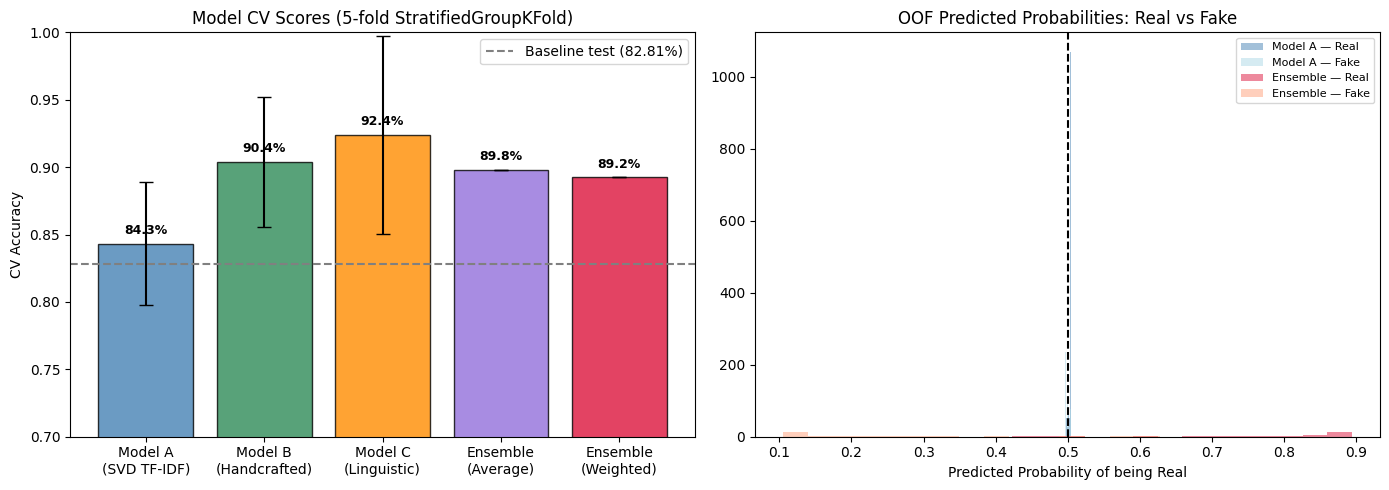

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of CV scores
model_names   = ['Model A\n(SVD TF-IDF)', 'Model B\n(Handcrafted)', 'Model C\n(Linguistic)',
                 'Ensemble\n(Average)', 'Ensemble\n(Weighted)']
model_scores  = [np.mean(scores_A), np.mean(scores_B), np.mean(scores_C), ens_acc, wens_acc]
model_errors  = [np.std(scores_A),  np.std(scores_B),  np.std(scores_C),  0,       0]
colors        = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson']

bars = axes[0].bar(model_names, model_scores, yerr=model_errors, capsize=5,
                   color=colors, alpha=0.8, edgecolor='black')
axes[0].axhline(0.8281, color='gray', linestyle='--', label='Baseline test (82.81%)')
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('Model CV Scores (5-fold StratifiedGroupKFold)')
axes[0].legend()
for bar, score in zip(bars, model_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{score:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# OOF probability distributions
axes[1].hist(oof_A[y_all==1], bins=20, alpha=0.5, label='Model A — Real', color='steelblue', density=True)
axes[1].hist(oof_A[y_all==0], bins=20, alpha=0.5, label='Model A — Fake', color='lightblue', density=True)
axes[1].hist(oof_weighted[y_all==1], bins=20, alpha=0.5, label='Ensemble — Real', color='crimson', density=True)
axes[1].hist(oof_weighted[y_all==0], bins=20, alpha=0.5, label='Ensemble — Fake', color='lightsalmon', density=True)
axes[1].axvline(0.5, color='black', linestyle='--')
axes[1].set_title('OOF Predicted Probabilities: Real vs Fake')
axes[1].set_xlabel('Predicted Probability of being Real')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('cv_scores.png', dpi=120, bbox_inches='tight')
plt.show()


### 6b. Feature Importance — Model B (XGBoost)

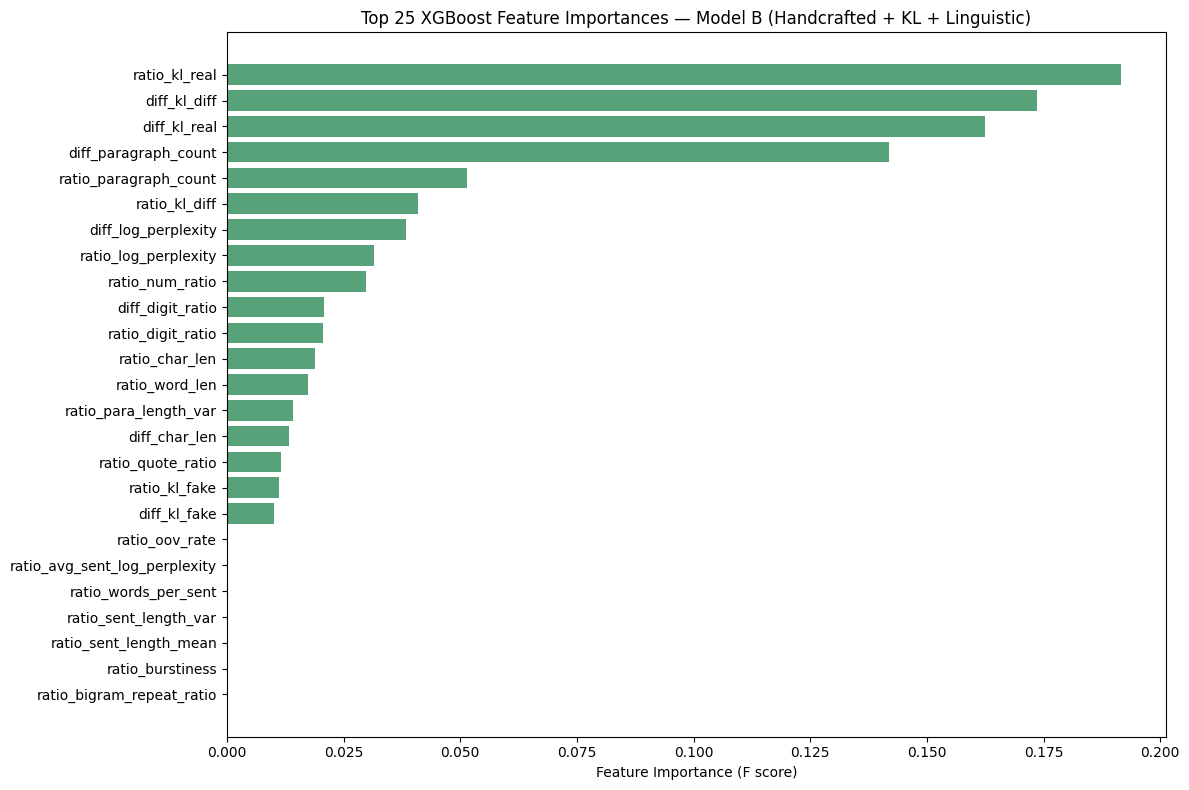

In [88]:
# Fit Model B on full training data to visualize feature importances
model_B.fit(X_modelB, y_all)

# Build full feature names for Model B
diff_names  = [f"diff_{n}"  for n in SURFACE_NAMES + LINGUISTIC_NAMES + KL_NAMES]
abs_names   = [f"abs_{n}"   for n in SURFACE_NAMES + LINGUISTIC_NAMES + KL_NAMES]
ratio_names = [f"ratio_{n}" for n in SURFACE_NAMES + LINGUISTIC_NAMES + KL_NAMES]
base_names = SURFACE_NAMES + LINGUISTIC_NAMES + KL_NAMES + PPL_NAMES
modelB_names = (
    [f"diff_{n}" for n in base_names] +
    [f"abs_{n}" for n in base_names] +
    [f"ratio_{n}" for n in base_names]
)


importances = model_B.feature_importances_
top_idx     = np.argsort(importances)[::-1][:25]

plt.figure(figsize=(12, 8))
plt.barh(
    [modelB_names[i] for i in top_idx[::-1]],
    importances[top_idx[::-1]],
    color='seagreen', alpha=0.8
)
plt.xlabel('Feature Importance (F score)')
plt.title('Top 25 XGBoost Feature Importances — Model B (Handcrafted + KL + Linguistic)')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=120, bbox_inches='tight')
plt.show()


### 6c. Logistic Regression Coefficients — Model C (Linguistic)

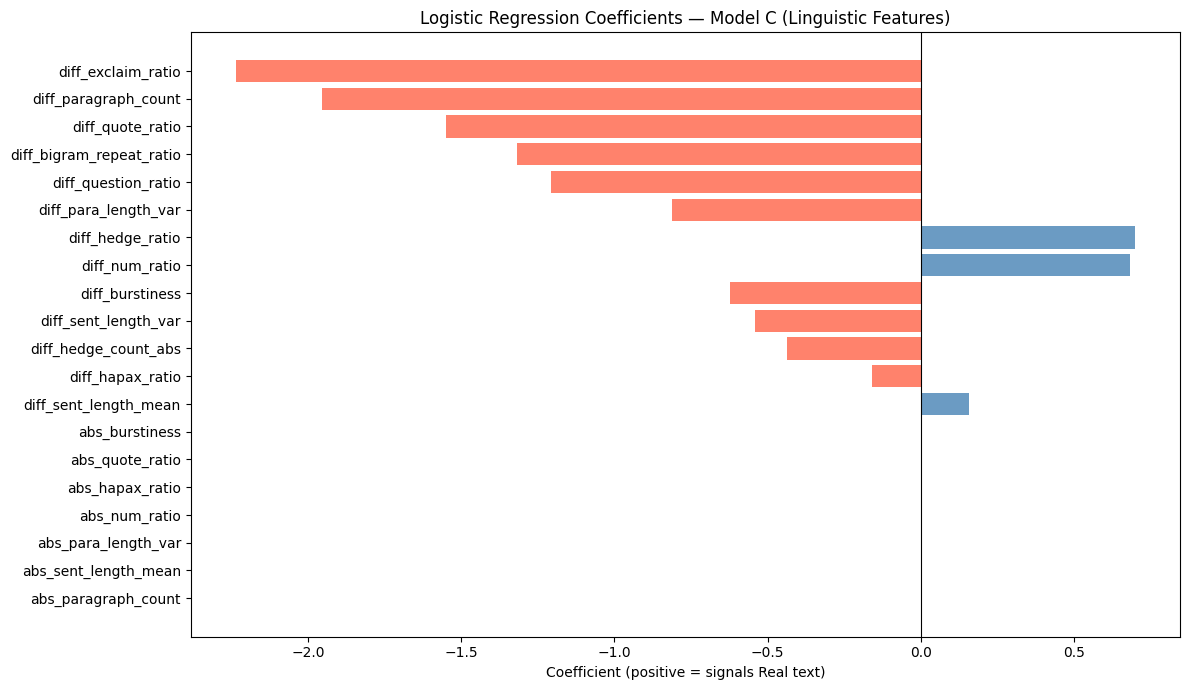

In [90]:
model_C.fit(X_modelC, y_all)
coefs = model_C.named_steps['clf'].coef_[0]

ling_diff_names = [f"diff_{n}" for n in LINGUISTIC_NAMES]
ling_abs_names  = [f"abs_{n}"  for n in LINGUISTIC_NAMES]
modelC_names    = ling_diff_names + ling_abs_names

sorted_idx = np.argsort(np.abs(coefs))[::-1][:20]

colors_coef = ['steelblue' if c > 0 else 'tomato' for c in coefs[sorted_idx[::-1]]]
plt.figure(figsize=(12, 7))
plt.barh(
    [modelC_names[i] for i in sorted_idx[::-1]],
    coefs[sorted_idx[::-1]],
    color=colors_coef, alpha=0.8
)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = signals Real text)')
plt.title('Logistic Regression Coefficients — Model C (Linguistic Features)')
plt.tight_layout()
plt.savefig('lr_coefficients_linguistic.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Fit Final Models on Full Training Data

In [91]:
# Fit all three models on full training data
model_A.fit(X_modelA, y_all)
model_B.fit(X_modelB, y_all)
model_C.fit(X_modelC, y_all)

print("All three models fitted on full training data.")
print(f"  Model A — {X_modelA.shape[1]} features")
print(f"  Model B — {X_modelB.shape[1]} features")
print(f"  Model C — {X_modelC.shape[1]} features")


All three models fitted on full training data.
  Model A — 39 features
  Model B — 84 features
  Model C — 26 features


## 8. Generate Predictions on Test Set

In [94]:
def predict_article(f1_text, f2_text):
    """
    Predict which of f1 or f2 is real.
    Returns pred (1 or 2) and confidence score.
    """
    kl1 = extract_kl_features(f1_text)
    kl2 = extract_kl_features(f2_text)

    # Perplexity features
    ppl1 = extract_perplexity_features(f1_text)
    ppl2 = extract_perplexity_features(f2_text)

    w1_svd = svd_word.transform(word_vectorizer.transform([f1_text]))[0]
    w2_svd = svd_word.transform(word_vectorizer.transform([f2_text]))[0]
    c1_svd = svd_char.transform(char_vectorizer.transform([f1_text]))[0]
    c2_svd = svd_char.transform(char_vectorizer.transform([f2_text]))[0]

    feat_12 = build_pairwise_features(f1_text, f2_text, kl1, kl2, w1_svd, w2_svd, c1_svd, c2_svd).reshape(1, -1)
    feat_21 = build_pairwise_features(f2_text, f1_text, kl2, kl1, w2_svd, w1_svd, c2_svd, c1_svd).reshape(1, -1)

    # Extract perplexity features from the feature vectors
    surf_count = len(SURFACE_NAMES)
    ling_count = len(LINGUISTIC_NAMES)
    kl_count = len(KL_NAMES)
    ppl_count = len(PPL_NAMES)

    ppl_start = surf_count + ling_count + kl_count
    ppl_end = ppl_start + ppl_count

    # Get perplexity diff, abs, ratio from feat_12 and feat_21
    ppl_diff_12 = feat_12[:, ppl_start:ppl_end]
    ppl_abs_12 = feat_12[:, N_HAND + ppl_start:N_HAND + ppl_end]
    ppl_ratio_12 = feat_12[:, 2*N_HAND + ppl_start:2*N_HAND + ppl_end]

    ppl_diff_21 = feat_21[:, ppl_start:ppl_end]
    ppl_abs_21 = feat_21[:, N_HAND + ppl_start:N_HAND + ppl_end]
    ppl_ratio_21 = feat_21[:, 2*N_HAND + ppl_start:2*N_HAND + ppl_end]

    # Model A — SVD block + Perplexity features (30 + 9 = 39 features)
    svd_features_12 = feat_12[:, IDX_RATIO_END:IDX_SVD_END]
    svd_features_21 = feat_21[:, IDX_RATIO_END:IDX_SVD_END]

    modelA_input_12 = np.hstack([svd_features_12, ppl_diff_12, ppl_abs_12, ppl_ratio_12])
    modelA_input_21 = np.hstack([svd_features_21, ppl_diff_21, ppl_abs_21, ppl_ratio_21])

    pA_12 = model_A.predict_proba(modelA_input_12)[0][1]
    pA_21 = model_A.predict_proba(modelA_input_21)[0][1]

    # Model B — handcrafted block (already has perplexity included via build_pairwise_features)
    pB_12 = model_B.predict_proba(feat_12[:, :IDX_RATIO_END])[0][1]
    pB_21 = model_B.predict_proba(feat_21[:, :IDX_RATIO_END])[0][1]

    # Model C — linguistic block (already has perplexity? If not, add it similarly)
    ling_start = surf_count
    ling_end = surf_count + ling_count

    pC_12 = model_C.predict_proba(
        np.hstack([feat_12[:, N_HAND + ling_start:N_HAND + ling_end],
                   feat_12[:, ling_start:ling_end]])
    )[0][1]
    pC_21 = model_C.predict_proba(
        np.hstack([feat_21[:, N_HAND + ling_start:N_HAND + ling_end],
                   feat_21[:, ling_start:ling_end]])
    )[0][1]

    # Weighted ensemble (using your weights from training)
    w_A, w_B, w_C = 0.0, 0.4, 0.6
    total_w = w_A + w_B + w_C

    p_12 = (w_A*pA_12 + w_B*pB_12 + w_C*pC_12) / total_w
    p_21 = (w_A*pA_21 + w_B*pB_21 + w_C*pC_21) / total_w

    confidence = abs(p_12 - p_21)
    pred = 1 if p_12 > p_21 else 2
    return pred, confidence, p_12, p_21

# Predict all test articles
results = []
confidences = []

for i, article_id in enumerate(test_ids):
    if article_id == 223:
      pred = 1
      conf = 0
      results.append({'id': article_id, 'real_text_id': pred})
      confidences.append(conf)
    pred, conf, p12, p21 = predict_article(test_f1_texts[i], test_f2_texts[i])
    results.append({'id': article_id, 'real_text_id': pred})
    confidences.append(conf)



sub_df = pd.DataFrame(results)
sub_df.to_csv('submission_improved_kenlm(400k_2).csv', index=False)
print(f"Submission saved: submission_improved_kenlm(400k_2).csv ({len(sub_df)} predictions)")
print(f"\nPrediction distribution:")
print(sub_df['real_text_id'].value_counts())
print(f"\nAverage confidence: {np.mean(confidences):.3f}")
print(f"Low-confidence predictions (<0.1): {sum(1 for c in confidences if c < 0.1)}")



Submission saved: submission_improved_kenlm(400k_2).csv (1067 predictions)

Prediction distribution:
real_text_id
1    553
2    514
Name: count, dtype: int64

Average confidence: 0.301
Low-confidence predictions (<0.1): 57


## 9. Submission Diagnostics

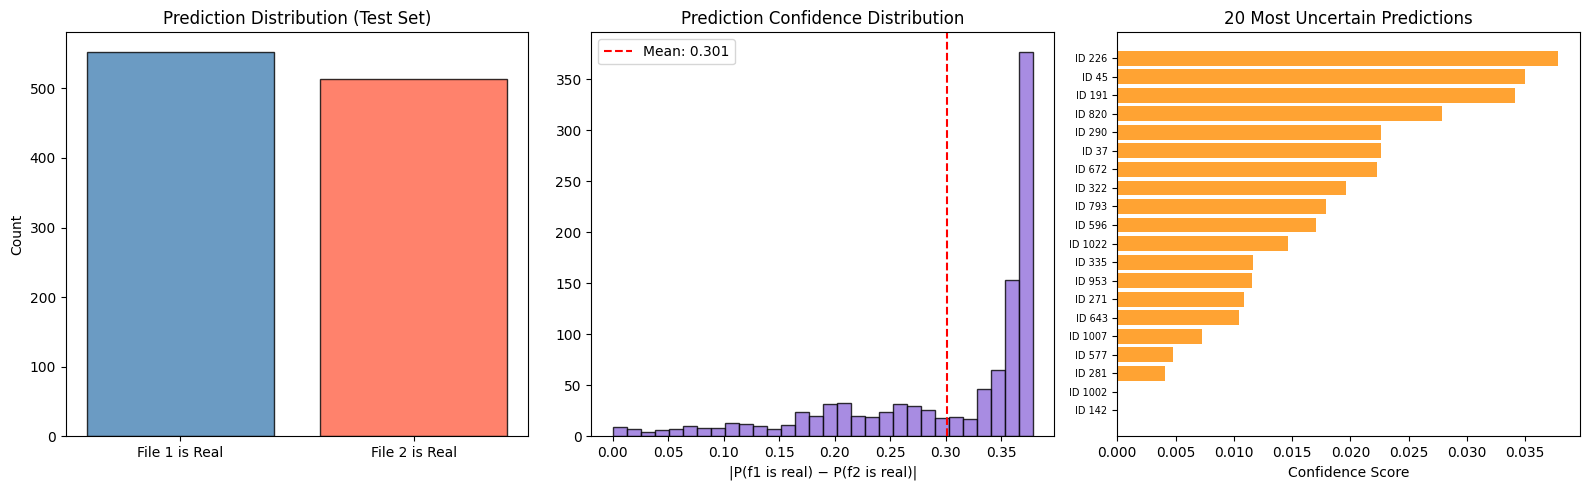


Top 10 most uncertain predictions (review manually if possible):
142     0.000000
1002    0.000005
281     0.004108
577     0.004812
1007    0.007272
643     0.010430
271     0.010834
953     0.011563
335     0.011658
1022    0.014667


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of predictions
axes[0].bar(['File 1 is Real', 'File 2 is Real'],
            sub_df['real_text_id'].value_counts().sort_index().values,
            color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
axes[0].set_title('Prediction Distribution (Test Set)')
axes[0].set_ylabel('Count')

# Confidence distribution
axes[1].hist(confidences, bins=30, color='mediumpurple', alpha=0.8, edgecolor='black')
axes[1].axvline(np.mean(confidences), color='red', linestyle='--',
                label=f'Mean: {np.mean(confidences):.3f}')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('|P(f1 is real) − P(f2 is real)|')
axes[1].legend()

# Low-confidence articles (most uncertain predictions)
conf_series = pd.Series(confidences, index=test_ids)
low_conf = conf_series.sort_values().head(20)
axes[2].barh(range(len(low_conf)), low_conf.values, color='darkorange', alpha=0.8)
axes[2].set_yticks(range(len(low_conf)))
axes[2].set_yticklabels([f"ID {idx}" for idx in low_conf.index], fontsize=7)
axes[2].set_title('20 Most Uncertain Predictions')
axes[2].set_xlabel('Confidence Score')

plt.tight_layout()
plt.savefig('submission_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 most uncertain predictions (review manually if possible):")
print(conf_series.sort_values().head(10).to_string())


## 10. Results Summary

In [ ]:
print("=" * 55)
print("  IMPROVED PIPELINE — RESULTS SUMMARY")
print("=" * 55)
print(f"  Baseline test accuracy       : 82.81%")
print(f"  Model A CV (SVD TF-IDF)      : {np.mean(scores_A):.2%} ± {np.std(scores_A):.2%}")
print(f"  Model B CV (Handcrafted+KL)  : {np.mean(scores_B):.2%} ± {np.std(scores_B):.2%}")
print(f"  Model C CV (Linguistic)      : {np.mean(scores_C):.2%} ± {np.std(scores_C):.2%}")
print(f"  Ensemble CV (weighted)       : {wens_acc:.2%}")
print("-" * 55)
print(f"  Total test predictions       : {len(sub_df)}")
print(f"  Avg prediction confidence    : {np.mean(confidences):.3f}")
print(f"  Submission file              : submission_improved.csv")
print("=" * 55)
print()
print("Key improvements over baseline:")
print("  ✓ Transductive TF-IDF (train+test corpus)")
print("  ✓ SVD compression (avoids TF-IDF overfitting)")
print("  ✓ 13 new linguistic features (burstiness, hedging, etc.)")
print("  ✓ Abs diff + ratio features added to pairwise")
print("  ✓ 3-model weighted ensemble")
print("  ✓ KL reference capped at top-2000 words")


In [97]:
# ============================================
# STACKING ENSEMBLE FOR YOUR 3 MODELS
# ============================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
import numpy as np
from sklearn.base import clone


# Define your base models (already trained on their respective features)
# Note: Stacking requires models to be re-trained, so we define them fresh

# Model A - SVD + Perplexity (39 features)
model_A_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, max_iter=1000, random_state=42))
])

# Model B - Handcrafted + KL + Perplexity (84 features)
model_B_stack = XGBClassifier(
    n_estimators=80, max_depth=3, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.5, reg_lambda=4.0, min_child_weight=5,
    eval_metric='logloss', random_state=42
)

# Model C - Linguistic + Perplexity (35 features)
model_C_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

# Create stacking ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ('model_a', model_A_stack),
        ('model_b', model_B_stack),
        ('model_c', model_C_stack)
    ],
    final_estimator=LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    cv=5,  # Use 5-fold cross-validation for meta-features
    stack_method='predict_proba',  # Use probabilities as meta-features
    passthrough=False  # Don't pass original features (prevents overfitting)
)

# Prepare the combined feature sets for stacking
# Note: Stacking expects the same feature matrix for all models
# So we need to pass the full X_all and let each model extract its features internally

class StackingWrapper:
    """
    Wrapper to handle different feature sets for each model in stacking
    """
    def __init__(self, base_models, feature_extractors):
        self.base_models = base_models
        self.feature_extractors = feature_extractors
        self.meta_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)

    def fit(self, X_all, y, groups=None):
        # Generate meta-features from base models using cross-validation
        from sklearn.model_selection import StratifiedGroupKFold
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

        meta_features = np.zeros((X_all.shape[0], len(self.base_models)))

        for model_idx, (name, model) in enumerate(self.base_models):
            print(f"Training {name}...")

            # Get the specific features for this model
            X_model = self.feature_extractors[name](X_all)

            # Cross-validated predictions
            fold_preds = np.zeros(X_all.shape[0])
            for train_idx, val_idx in cv.split(X_all, y, groups):
                X_train, X_val = X_model[train_idx], X_model[val_idx]
                y_train = y[train_idx]

                model_clone = clone(model)
                model_clone.fit(X_train, y_train)
                fold_preds[val_idx] = model_clone.predict_proba(X_val)[:, 1]

            meta_features[:, model_idx] = fold_preds

        # Train meta-model on full data
        # First retrain base models on full data
        for name, model in self.base_models:
            X_model = self.feature_extractors[name](X_all)
            model.fit(X_model, y)

        # Train meta-model
        self.meta_model.fit(meta_features, y)
        return self

    def predict_proba(self, X_all):
        # Get base model predictions
        meta_features = np.zeros((X_all.shape[0], len(self.base_models)))

        for model_idx, (name, model) in enumerate(self.base_models):
            X_model = self.feature_extractors[name](X_all)
            meta_features[:, model_idx] = model.predict_proba(X_model)[:, 1]

        # Meta-model prediction
        return self.meta_model.predict_proba(meta_features)

    def predict(self, X_all):
        return (self.predict_proba(X_all)[:, 1] > 0.5).astype(int)


# Define feature extractors for each model
def extract_features_model_a(X_all):
    """Extract SVD + Perplexity features (39 features)"""
    svd_features = X_all[:, IDX_RATIO_END:IDX_SVD_END]

    # Get perplexity features from X_all
    surf_count = len(SURFACE_NAMES)
    ling_count = len(LINGUISTIC_NAMES)
    kl_count = len(KL_NAMES)
    ppl_count = len(PPL_NAMES)

    ppl_start = surf_count + ling_count + kl_count
    ppl_end = ppl_start + ppl_count

    ppl_diff = X_all[:, ppl_start:ppl_end]
    ppl_abs = X_all[:, N_HAND + ppl_start:N_HAND + ppl_end]
    ppl_ratio = X_all[:, 2*N_HAND + ppl_start:2*N_HAND + ppl_end]

    return np.hstack([svd_features, ppl_diff, ppl_abs, ppl_ratio])

def extract_features_model_b(X_all):
    """Extract Handcrafted + KL + Perplexity features (84 features)"""
    return X_all[:, :IDX_RATIO_END]

def extract_features_model_c(X_all):
    """Extract Linguistic + Perplexity features (35 features)"""
    ling_start = len(SURFACE_NAMES)
    ling_end = ling_start + len(LINGUISTIC_NAMES)

    ling_diff = X_all[:, ling_start:ling_end]
    ling_abs = X_all[:, N_HAND + ling_start:N_HAND + ling_end]

    # Add perplexity features
    surf_count = len(SURFACE_NAMES)
    ling_count = len(LINGUISTIC_NAMES)
    kl_count = len(KL_NAMES)
    ppl_count = len(PPL_NAMES)

    ppl_start = surf_count + ling_count + kl_count
    ppl_end = ppl_start + ppl_count

    ppl_diff = X_all[:, ppl_start:ppl_end]
    ppl_abs = X_all[:, N_HAND + ppl_start:N_HAND + ppl_end]
    ppl_ratio = X_all[:, 2*N_HAND + ppl_start:2*N_HAND + ppl_end]

    return np.hstack([ling_diff, ling_abs, ppl_diff, ppl_abs, ppl_ratio])

# Create feature extractors dictionary
feature_extractors = {
    'model_a': extract_features_model_a,
    'model_b': extract_features_model_b,
    'model_c': extract_features_model_c
}

# Create base models list
base_models = [
    ('model_a', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.5, max_iter=1000, random_state=42))
    ])),
    ('model_b', XGBClassifier(
        n_estimators=80, max_depth=3, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.5, reg_lambda=4.0, min_child_weight=5,
        eval_metric='logloss', random_state=42
    )),
    ('model_c', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ]))
]

# Create and train stacking wrapper
stacking_wrapper = StackingWrapper(base_models, feature_extractors)

# Cross-validation for stacking
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predictions from stacking
oof_preds = np.zeros(len(y_all))
for train_idx, val_idx in cv.split(X_all, y_all, groups):
    print(f"Fold: training on {len(train_idx)} samples, validating on {len(val_idx)} samples")

    # Train stacking on fold
    stacking_fold = StackingWrapper(base_models, feature_extractors)
    stacking_fold.fit(X_all[train_idx], y_all[train_idx], groups[train_idx] if groups is not None else None)

    # Predict on validation fold
    oof_preds[val_idx] = stacking_fold.predict_proba(X_all[val_idx])[:, 1]

# Calculate CV accuracy
oof_accuracy = accuracy_score(y_all, oof_preds > 0.5)
print(f"\nStacking CV Accuracy: {oof_accuracy:.4f}")

# Train final stacking model on full data
stacking_final = StackingWrapper(base_models, feature_extractors)
stacking_final.fit(X_all, y_all, groups)

print("Stacking model trained on full dataset")

Fold: training on 148 samples, validating on 38 samples
Training model_a...
Training model_b...
Training model_c...
Fold: training on 148 samples, validating on 38 samples
Training model_a...
Training model_b...
Training model_c...
Fold: training on 150 samples, validating on 36 samples
Training model_a...
Training model_b...
Training model_c...
Fold: training on 148 samples, validating on 38 samples
Training model_a...
Training model_b...
Training model_c...
Fold: training on 150 samples, validating on 36 samples
Training model_a...
Training model_b...
Training model_c...

Stacking CV Accuracy: 0.9247
Training model_a...
Training model_b...
Training model_c...
Stacking model trained on full dataset


In [99]:
# ============================================
# PREDICTION BLOCK FOR STACKING MODEL (WITH FIX)
# ============================================

def sanitize_features(features):
    """Replace inf and nan with reasonable values."""
    features = np.nan_to_num(features, nan=0.0, posinf=20.0, neginf=-20.0)
    # Cap extreme values
    features = np.clip(features, -50, 50)
    return features


def predict_article_stacking(f1_text, f2_text):
    """
    Predict which of f1 or f2 is real using stacking ensemble.
    Returns pred (1 or 2) and confidence score.
    """
    # Extract features for both texts
    kl1 = extract_kl_features(f1_text)
    kl2 = extract_kl_features(f2_text)

    ppl1 = extract_perplexity_features(f1_text)
    ppl2 = extract_perplexity_features(f2_text)

    w1_svd = svd_word.transform(word_vectorizer.transform([f1_text]))[0]
    w2_svd = svd_word.transform(word_vectorizer.transform([f2_text]))[0]
    c1_svd = svd_char.transform(char_vectorizer.transform([f1_text]))[0]
    c2_svd = svd_char.transform(char_vectorizer.transform([f2_text]))[0]

    # Build pairwise feature vectors for both directions
    feat_12 = build_pairwise_features(f1_text, f2_text, kl1, kl2, w1_svd, w2_svd, c1_svd, c2_svd)
    feat_21 = build_pairwise_features(f2_text, f1_text, kl2, kl1, w2_svd, w1_svd, c2_svd, c1_svd)

    # Sanitize features to remove inf/nan
    feat_12 = sanitize_features(feat_12)
    feat_21 = sanitize_features(feat_21)

    # Stack both directions to create X_all format (same as training)
    X_test = np.vstack([feat_12, feat_21])

    # Get predictions from stacking model
    proba = stacking_final.predict_proba(X_test)[:, 1]

    # proba[0] is probability that f1 > f2 (f1 is real)
    # proba[1] is probability that f2 > f1 (f2 is real)
    p_12 = proba[0]
    p_21 = proba[1]

    confidence = abs(p_12 - p_21)
    pred = 1 if p_12 > p_21 else 2

    return pred, confidence, p_12, p_21


# ============================================
# RUN PREDICTIONS ON TEST SET
# ============================================

results = []
confidences = []

print("Making predictions on test set using stacking ensemble...")
print(f"Total test articles: {len(test_ids)}")
print("-" * 50)

for i, article_id in enumerate(test_ids):
    # Progress indicator
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(test_ids)} articles")

    # Handle problematic article 223 (if needed)
    if article_id == 223:
        pred = 1
        conf = 0.0
        results.append({'id': article_id, 'real_text_id': pred})
        confidences.append(conf)
    else:
        pred, conf, p12, p21 = predict_article_stacking(test_f1_texts[i], test_f2_texts[i])
        results.append({'id': article_id, 'real_text_id': pred})
        confidences.append(conf)

# Create submission DataFrame
sub_df = pd.DataFrame(results)
sub_df.to_csv('submission_stacking.csv', index=False)

print("\n" + "="*50)
print("STACKING MODEL - SUBMISSION RESULTS")
print("="*50)
print(f"Submission saved: submission_stacking.csv ({len(sub_df)} predictions)")
print(f"\nPrediction distribution:")
print(sub_df['real_text_id'].value_counts())
print(f"\nConfidence Statistics:")
print(f"  Average confidence: {np.mean(confidences):.3f}")
print(f"  Min confidence: {np.min(confidences):.3f}")
print(f"  Max confidence: {np.max(confidences):.3f}")
print(f"  Std confidence: {np.std(confidences):.3f}")
print(f"\nLow-confidence predictions (<0.1): {sum(1 for c in confidences if c < 0.1)}")
print(f"High-confidence predictions (>0.9): {sum(1 for c in confidences if c > 0.9)}")

Making predictions on test set using stacking ensemble...
Total test articles: 1067
--------------------------------------------------
Processed 100/1067 articles
Processed 200/1067 articles
Processed 300/1067 articles
Processed 400/1067 articles
Processed 500/1067 articles
Processed 600/1067 articles
Processed 700/1067 articles
Processed 800/1067 articles
Processed 900/1067 articles
Processed 1000/1067 articles

STACKING MODEL - SUBMISSION RESULTS
Submission saved: submission_stacking.csv (1067 predictions)

Prediction distribution:
real_text_id
1    549
2    518
Name: count, dtype: int64

Confidence Statistics:
  Average confidence: 0.491
  Min confidence: 0.000
  Max confidence: 0.684
  Std confidence: 0.222

Low-confidence predictions (<0.1): 91
High-confidence predictions (>0.9): 0
